In [1]:
# Jeffrey Pan and Jocelyn Min
# DS 4420
# Final Project - CNN

In [2]:
# pip install -r requirements.txt

# install for first time users

In [3]:
import numpy as np
from tensorflow.keras.layers import Conv2D,Dense,Dropout,Flatten,MaxPooling2D,BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
import os
import cv2
import dotenv
from torch.utils.data import DataLoader, TensorDataset
import torch

In [4]:
# get environment variables
dotenv.load_dotenv()

True

In [5]:
dir = os.getenv("data_path") + '\\satellite\\train'
x = []
y = []
for direct in os.listdir(dir):
    print("Loading dataset training {}".format(direct))
    for filename in os.listdir(os.path.join(dir,direct)):
        img_path = os.path.join(dir,direct,filename)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (32,32))
        img = np.array(img)
        img = img/255
        x.append(img)
        y.append(direct)

Loading dataset training fire
Loading dataset training nofire


In [6]:
dir = os.getenv("data_path") + '\\satellite\\val'
x_val=[]
y_val=[]
for direct in os.listdir(dir):
    print("Loading dataset validation {}".format(direct))
    for filename in os.listdir(os.path.join(dir,direct)):
        img_path = os.path.join(dir,direct,filename)
        image = cv2.imread(img_path)
        if image is None:
            print("Error loading image: {}".format(img_path))
            continue
        image = cv2.resize(image,(32,32))
        image = np.array(image)
        image = image/255
        x_val.append(image)
        y_val.append(direct)

Loading dataset validation fire
Error loading image: C:\Users\panje\Documents\GitHub\DS-4420-Final-Project\data\satellite\val\fire\desktop.ini
Loading dataset validation nofire


In [7]:
dir = os.getenv("data_path") + '\\satellite\\test'
for direct in os.listdir(dir):
    print("Loading dataset test and combining with val {}".format(direct))
    for filename in os.listdir(os.path.join(dir,direct)):
        img_path = os.path.join(dir,direct,filename)
        image = cv2.imread(img_path)
        if image is None:
            print("Error loading image: {}".format(img_path))
            continue
        image = cv2.resize(image,(32,32))
        image = np.array(image)
        image = image/255
        x_val.append(image)
        y_val.append(direct)

Loading dataset test and combining with val fire
Loading dataset test and combining with val nofire


In [8]:
# Encode labels and one-hot encode them for training data
label_encode = LabelEncoder()
label_y = label_encode.fit_transform(y)  # Encode training labels as integers
one_hot_y = to_categorical(label_y)  # One-hot encode the training labels

# Encode labels and one-hot encode them for testing data
label_y_val = label_encode.transform(y_val)  # Encode testing labels using the same encoder
one_hot_y_val = to_categorical(label_y_val)  # One-hot encode the testing labels

# Convert features to NumPy arrays
x = np.array(x)  # Training features
x_val = np.array(x_val)  # Testing features

# Convert data to PyTorch tensors
x_train_tensor = torch.tensor(x, dtype=torch.float32)
y_train_tensor = torch.tensor(one_hot_y, dtype=torch.float32)

x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
y_val_tensor = torch.tensor(one_hot_y_val, dtype=torch.float32)

# Create TensorDatasets
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Check shapes
print("x_train_tensor shape:", x_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("x_val_tensor shape:", x_val_tensor.shape)
print("y_val_tensor shape:", y_val_tensor.shape)

x_train_tensor shape: torch.Size([1887, 32, 32, 3])
y_train_tensor shape: torch.Size([1887, 2])
x_val_tensor shape: torch.Size([812, 32, 32, 3])
y_val_tensor shape: torch.Size([812, 2])


In [9]:
model = Sequential()

# Add a 2D convolutional layer with 32 filters, kernel size of (3, 3), 'same' padding, ReLU activation, and input shape (32, 32, 3)
model.add(Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3), activation='relu'))

# Add another 2D convolutional layer with 64 filters, kernel size of (3, 3), 'same' padding, and ReLU activation
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))

# Add a max pooling layer with a pool size of (2, 2)
model.add(MaxPooling2D(pool_size=(2, 2)))

# Add a batch normalization layer to normalize the activations
model.add(BatchNormalization())

# Flatten the 2D feature maps into a 1D feature vector
model.add(Flatten())

# Add a dropout layer with a dropout rate of 0.2 to prevent overfitting
model.add(Dropout(0.4))

# Add a dense (fully connected) layer with 64 units and ReLU activation
model.add(Dense(64, activation='relu'))

# Add the output dense layer with 2 units (for binary classification) and sigmoid activation
# model.add(Dense(2, activation='softmax'))
model.add(Dense(2, activation='sigmoid'))

c:\Users\panje\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,048,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,068,418 (4.08 MB)

 Trainable params: 1,068,290 (4.08 MB)

 Non-trainable params: 128 (512.00 B)

In [11]:
# FOR THE SIGMOID MODEL

model.compile(optimizer="SGD", loss="binary_crossentropy", metrics=["accuracy"])

# Train the model using the training data
history = model.fit(train_loader, epochs=50, validation_data=val_loader, verbose=1)


Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6461 - loss: 0.7026 - val_accuracy: 0.6675 - val_loss: 0.6700
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7585 - loss: 0.4861 - val_accuracy: 0.7106 - val_loss: 0.6401
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7892 - loss: 0.4421 - val_accuracy: 0.7057 - val_loss: 0.6192
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8160 - loss: 0.4051 - val_accuracy: 0.6786 - val_loss: 0.5902
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8245 - loss: 0.3950 - val_accuracy: 0.7562 - val_loss: 0.5520
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8126 - loss: 0.3928 - val_accuracy: 0.7315 - val_loss: 0.5173
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8486 - loss: 0.3516 - val_accuracy: 0.7759 - val_loss: 0.4745
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8405 - loss: 0.3530 - val_accuracy: 0.7722 - val_l

In [12]:
# Evaluate the model using the validation data
loss, accuracy = model.evaluate(val_loader)
print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7877 - loss: 0.6182
Validation Loss: 0.5373372435569763
Validation Accuracy: 0.8214285969734192


In [13]:
# model.compile(optimizer="SGD", loss="categorical_crossentropy", metrics=["accuracy"])

# # Train the model using the training data
# history = model.fit(train_loader, epochs=50, validation_data=val_loader, verbose = 1)

# # Evaluate the model using the validation data
# loss, accuracy = model.evaluate(val_loader)
# print("Validation Loss:", loss)
# print("Validation Accuracy:", accuracy)

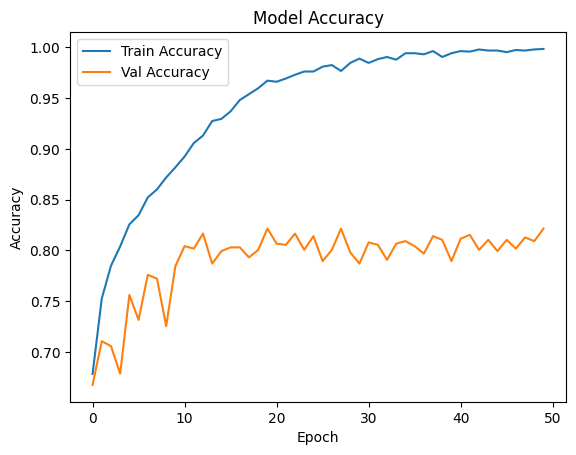

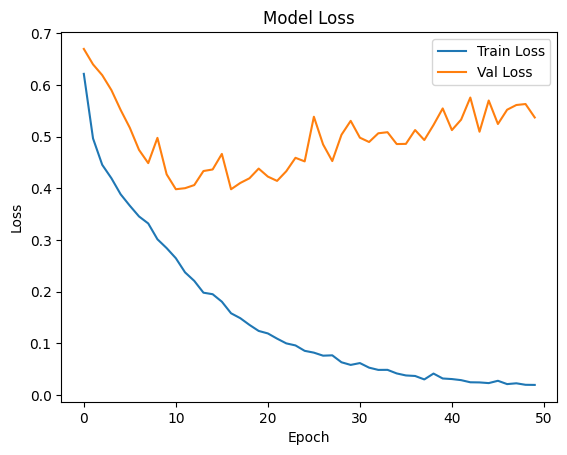

In [14]:
# trauning and validation loss and accuracy curves
import matplotlib.pyplot as plt

# Plot Accuracy
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot Loss
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


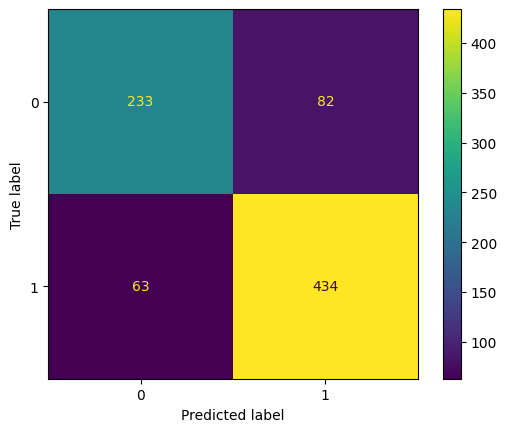

In [15]:
# confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_true = []
y_pred = []

for X, y in val_loader:
    preds = model.predict(X)
    y_true.extend(y.numpy().argmax(axis=1))
    y_pred.extend(preds.argmax(axis=1))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()